# Molecular dynamics simulations of a Lennard-Jones-like liquid

In a classical approximation, interactions between atoms consist of a repulsive term due to electron shell overlap and an attractive term due to dipole-dipole interactions. These terms are typically parametrized by the Lennard-Jones potential. For computational convenience, we use the Wang-Frenkel interaction potential between particles $i$ and $j$ instead


$$
U_{ij}^{\mathrm{WF}} =
\begin{cases}
\epsilon \left[ \left( \frac{\sigma}{r_{ij}} \right)^2 - 1 \right]
\left[ \left( \frac{r_c}{r_{ij}} \right)^2 - 1 \right]^2 & \text{if } r_{ij} < r_c \\
0 & \text{otherwise.}
\end{cases}
$$

with $\sigma$ and $\epsilon$ being phenomenological constants and $r_c$ being the cutoff distance. The distance between molecules is denoted $r_{ij}$. We consider a two-dimensional system of spherical molecules with periodic boundary conditions. The molecules all have the same mass $m$.

## 1. Initialization

### (a)

Write a script to generate the positions of a two-dimensional system of molecules with a packing fraction $\phi$, which is defined as

$$
\phi = \frac{N \pi \sigma^2}{A},
$$
with $N$ being the number of molecules and $A$ being the total surface area of
two-dimensional system. Make sure that the molecules do not overlap because
that would lead to very large energies

In [6]:
#1a
import numpy as np
import matplotlib.pyplot as plt 

#Constants
rc = 1.0
sigma = 1.0
epsilon = 1.0
phi = 0.5

#Parameter
N = 100

#function to generate positions with the given tensity 
def generate_positions(N, phi, sigma, factor = 1.0, max_trials=100000):
    positions = []
    cnt = 0

    #calculate A for the chosen N and sigma
    A = (N*np.pi*sigma**2) / phi 

    #quadradic field with sidelenght L
    L = np.sqrt(A)

    #calc minimal distance between two moleculecenters
    min_distance = 2* sigma * factor

    #try as long as their are N molecules or max_tails is reached
    while len(positions) < N and cnt < max_trials:
        p = np.array([np.random.uniform(0, L),
                      np.random.uniform(0, L)])

        # check if their is an overlap
        ok = True
        for q in positions:
            if np.linalg.norm(p - q) < min_distance:
                ok = False
                break

        if ok:
            positions.append(p)

        cnt += 1

    # if the number of paricles cannot be reached within the max 
    # nuber of trails stopp with the error 
    if len(positions) < N:
        raise RuntimeError("density not reachable.")

    return np.array(positions), L


positions, L = generate_positions(N, phi, sigma, 1.0, 1000000)

print("Box length L =", L)
print("Generated positions:")
print(positions)



Box length L = 25.066282746310005
Generated positions:
[[20.27946215 18.60420194]
 [19.34642602 13.77674164]
 [22.89028458  3.03116385]
 [22.87136585 11.35196723]
 [ 4.1881547  18.85410188]
 [ 5.80482916 15.89462996]
 [18.13041783 18.65143661]
 [18.19610632 23.2246104 ]
 [ 7.42568152 11.9634798 ]
 [14.1856473   9.58248416]
 [ 7.41432472 14.56306351]
 [ 4.18951091  9.2021514 ]
 [14.20672782 13.7339794 ]
 [11.42473454 17.33289267]
 [24.93916717 18.77962621]
 [22.27352583 23.85898814]
 [17.9626286   2.77605489]
 [20.0822325   8.71496185]
 [ 1.39787529 22.29985008]
 [ 0.23736112  0.75999442]
 [ 6.99309871 18.79123761]
 [ 8.42839663 23.43597547]
 [20.84445852 11.56172373]
 [11.56169797  4.24434155]
 [ 2.12936568  7.62606548]
 [ 6.95086057  3.32683432]
 [17.37012005 13.07068562]
 [ 3.70153711 24.1290374 ]
 [ 3.12701384  2.97136782]
 [ 1.45259513 20.09065805]
 [ 5.43423471 12.88227171]
 [17.52128438 20.81894063]
 [14.84793025  1.20684204]
 [23.37407617  6.75537721]
 [22.78976895 14.60123472]


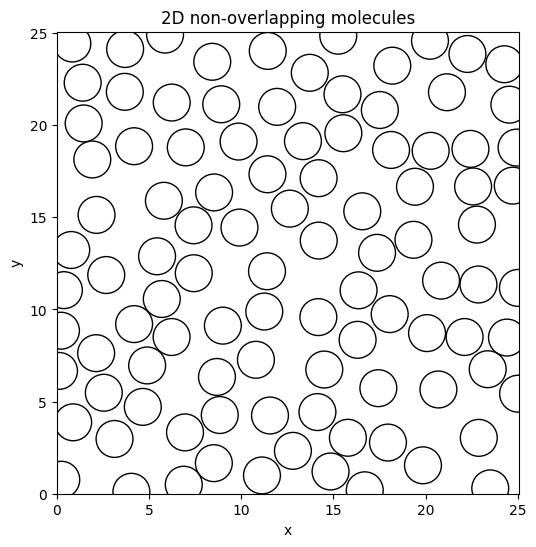

In [9]:
#Testfeld
# plot -> plot particles
fig, ax = plt.subplots(figsize=(6, 6))

for x, y in positions:
    circle = plt.Circle((x, y), sigma, fill=False)
    ax.add_patch(circle)

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_aspect('equal')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("2D non-overlapping molecules")
plt.show()

(b) Generate initial velocities for all particles by drawing independent velocities
in every dimension from a Gaussian distribution corresponding to an initial
temperature $T$ . Make sure that the velocity of the center of mass of the system
vanishes.

In [30]:
#1b
# function to generate the velocities
def generate_velocities(N, T, k_B, m):
    # for corresbondig to a Temp use a sigma_v(T)
    # Äquipartitionstheorem 1/2 kb T per dimension
    sigma_v = np.sqrt(k_B*T/m)
    # create velocities
    v = np.random.normal(0.0, sigma_v, size=(N, 2))

    # subtract center-of-mass velocity
    v_cm = np.mean(v, axis=0)
    v_cm_corr = v - v_cm

    return v, v_cm_corr 

# check the function (vanishes v of des center of mass)
N = 1000
m =1.0
k_B = 1.0
T = 1.0

v, v_cm_corr = generate_velocities(N, T, k_B, m)
print("Number of Values", np.shape(v))
print("Means of  direction (without COM correction):", np.mean(v, axis=0))
print("Means of  direction (with COM correction):", np.mean(v_cm_corr, axis=0))
#print(positions)


Number of Values (1000, 2)
Means of  direction (without COM correction): [0.00740286 0.01222731]
Means of  direction (with COM correction): [-1.7985613e-17  9.1038288e-18]


2 Force calculation
The force between the molecules is given as usual by $f_{ij} = −\nabla U^{WF}_{ij}$ . The forces
are assumed to be pairwise additive.

    (a) Write a script to calculate the force on all particles from the positions of the
particles. Take care that periodic boundary conditions are used.

In [ ]:
#2a

    (b) Include a calculation of the total potential energy of the system in the calculation
of the forces.

In [ ]:
#2b

(c) Evaluate the scaling of computational cost of the force calculation with the num-
ber of particles $N$ .

In [ ]:
#2c

3 Integration of the equations of motion

(a)

Nondimensionalize the equations and pick a sensible time step in terms of $\sigma$, $\epsilon$ and the particle mass $m$.

The velocity-Verlet algorithm for positions $r$, velocities $v$ and forces $f$ consists of the following steps:

$$
v\left(t + \frac{\Delta t}{2}\right) = v(t) + \frac{f(t)}{2m}\Delta t
$$

$$
r(t + \Delta t) = r(t) + v\left(t + \frac{\Delta t}{2}\right)\Delta t
$$

$$
f(t + \Delta t) = f(r(t + \Delta t))
$$

$$
v(t + \Delta t) = v\left(t + \frac{\Delta t}{2}\right) + \frac{f(t+\Delta t)}{2m}\Delta t
$$


In [ ]:
#3a

(b)

Implement the velocity-Verlet algorithm to solve the equations of motion.

In [ ]:
#3b

(c)

Calculate the kinetic energy at every integer time step and plot the total energy and the temperature as a function of time.

In [ ]:
#3c
